In [2]:
!pip install pandas azure-storage-blob
connect_str ="DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = 'businesscases'
blob_name = "Final_Mission_loan_data.csv"



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install pandas
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str ="DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = 'businesscases'
blob_name = "Final_Mission_loan_data.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df = pd.read_csv(StringIO(csv_content))

# Display all rows
display(df)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,male,Associate,47971,6,RENT,15000,MEDICAL,15.66,0.31,3,645,No,1
44996,37,female,Associate,65800,17,RENT,9000,HOMEIMPROVEMENT,14.07,0.14,11,621,No,1
44997,33,male,Associate,56942,7,RENT,2771,DEBTCONSOLIDATION,10.02,0.05,10,668,No,1
44998,29,male,Bachelor,33164,4,RENT,12000,EDUCATION,13.23,0.36,6,604,No,1


In [4]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Inspect Data types
print("Data Types:")
print(df.dtypes)

# Missing values (count)
print("\nMissing Values (Count):")
print(df.isnull().sum())

Data Types:
person_age                          int64
person_gender                         str
person_education                      str
person_income                       int64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                           int64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object

Missing Values (Count):
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
c

In [7]:
df.columns


Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

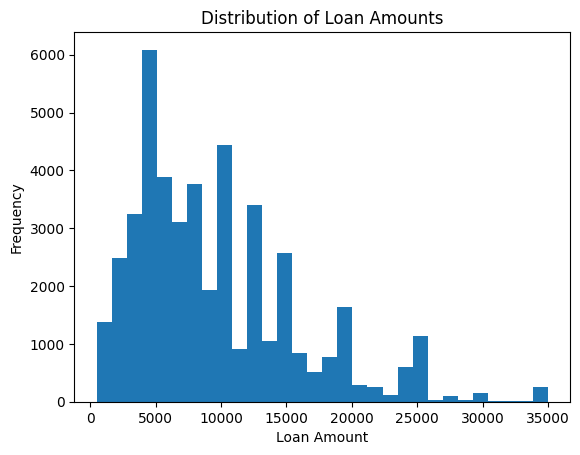

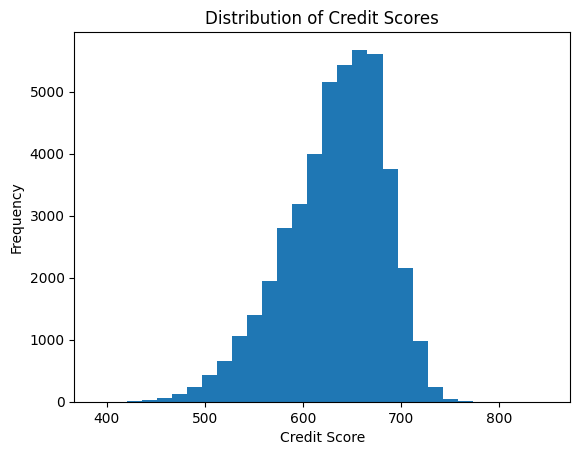

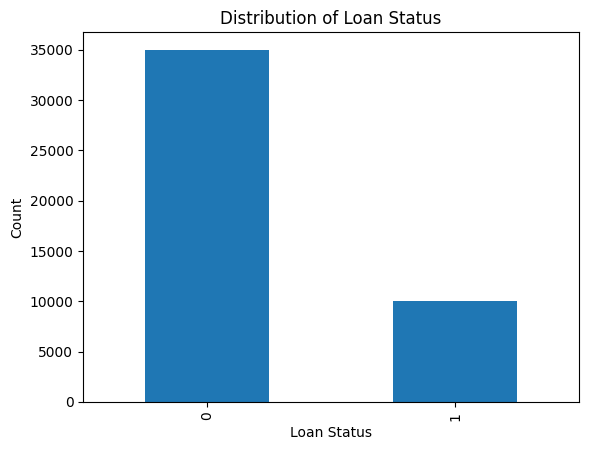

In [9]:
import matplotlib.pyplot as plt

#Distribution of Loan Amounts
plt.figure()
plt.hist(df['loan_amnt'].dropna(), bins=30)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


#Distribution of Credit Scores
plt.figure()
plt.hist(df['credit_score'].dropna(), bins=30)
plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()


#Distribution of Loan Status
plt.figure()
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

Correlation with Loan Status:
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64
Correlation with Loan Status:
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64


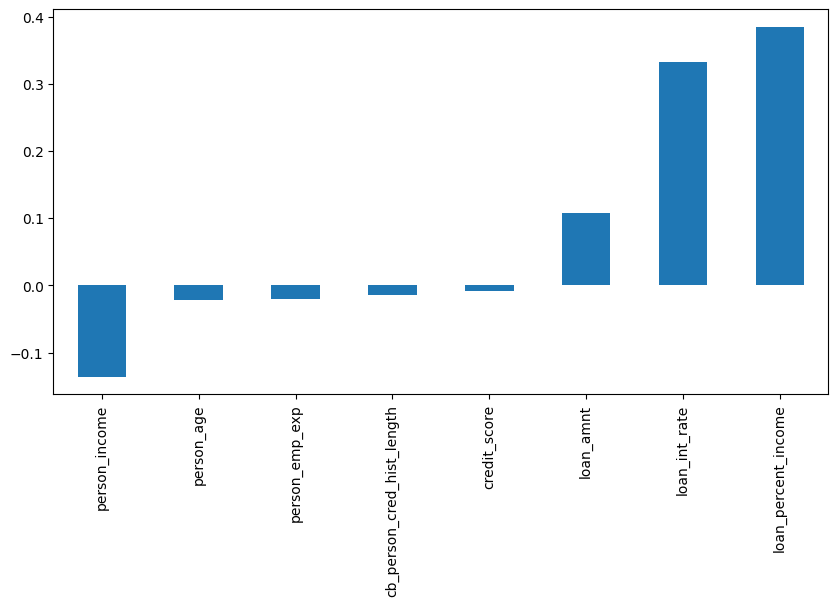

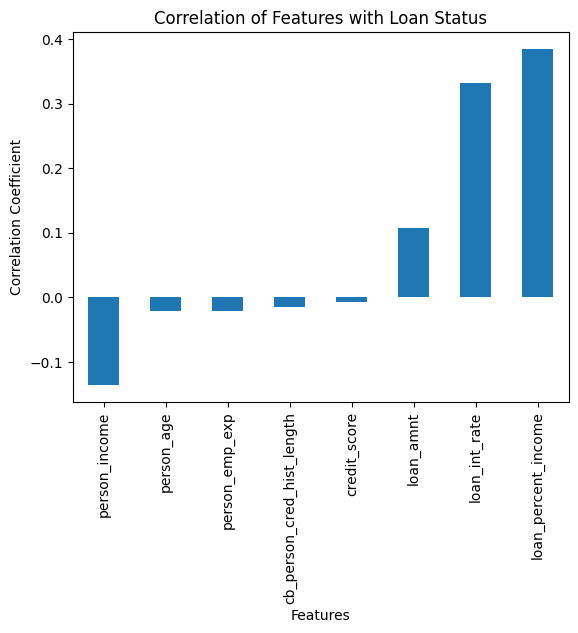

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Make a copy
df_corr = df.copy()

# Convert loan_status to numeric encoding
df_corr['loan_status'] = df_corr['loan_status'].astype('category').cat.codes

# Ensure loan_status is included in numeric_df
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# If loan_status somehow is missing, add it explicitly
if 'loan_status' not in numeric_df.columns:
    numeric_df['loan_status'] = df_corr['loan_status']

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Extract correlation with target
target_correlation = correlation_matrix['loan_status'].drop('loan_status')

# Print sorted correlations
print("Correlation with Loan Status:")
print(target_correlation.sort_values(ascending=False))

# Plot correlations
plt.figure(figsize=(10,5))
target_correlation.sort_values().plot(kind='bar')


# Extract correlation with target
target_correlation = correlation_matrix['loan_status'].drop('loan_status')

# Print sorted correlations
print("Correlation with Loan Status:")
print(target_correlation.sort_values(ascending=False))

# Plot correlations
plt.figure()
target_correlation.sort_values().plot(kind='bar')
plt.title("Correlation of Features with Loan Status")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=90)
plt.show()

In [11]:
# Check for missing values

missing_values = df.isnull()
print(df)
df = df.dropna()

       person_age person_gender person_education  person_income  \
0              22        female           Master          71948   
1              21        female      High School          12282   
2              25        female      High School          12438   
3              23        female         Bachelor          79753   
4              24          male           Master          66135   
...           ...           ...              ...            ...   
44995          27          male        Associate          47971   
44996          37        female        Associate          65800   
44997          33          male        Associate          56942   
44998          29          male         Bachelor          33164   
44999          24          male      High School          51609   

       person_emp_exp person_home_ownership  loan_amnt        loan_intent  \
0                   0                  RENT      35000           PERSONAL   
1                   0                   O

In [12]:
# List of categorical columns
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership']

# Convert each categorical column to numeric codes
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# Check the transformed data
print(df[categorical_cols].head())

   person_gender  person_education  person_home_ownership
0              0                 4                      3
1              0                 3                      2
2              0                 3                      0
3              0                 1                      3
4              1                 4                      3


In [13]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# Target variable
y = df['loan_status']

# Features (all columns except target)
X = df.drop('loan_status', axis=1)

# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45000, 13)
Target shape: (45000,)


In [15]:
X = df[['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
        'loan_int_rate', 'loan_percent_income',
        'cb_person_cred_hist_length', 'credit_score']]

y = df['loan_status']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (36000, 8), Testing Data: (9000, 8)


In [19]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model_lr = LinearRegression()

# Fit the model on the training data
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(X_test)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict test data
y_pred = log_model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.8247777777777778


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf}")

Random Forest Model Accuracy: 0.8692222222222222


In [22]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"Gradient Boosting Model Accuracy: {accuracy_gb}")

Gradient Boosting Model Accuracy: 0.8561111111111112


In [24]:
comparison_table = pd.DataFrame({
    'Actual': y_test,
    'Logistic_Regression': y_pred,
    'Random_Forest': y_pred_rf,
    'Gradient_Boosting': y_pred_gb
})

print(comparison_table.head())

       Actual  Logistic_Regression  Random_Forest  Gradient_Boosting
37979       0                    0              0                  0
9911        0                    0              0                  0
43386       1                    0              1                  1
13822       0                    0              0                  0
44810       1                    0              1                  1


In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Accuracy Scores:")
print(f"Logistic Regression: {accuracy_log}")
print(f"Random Forest: {accuracy_rf}")
print(f"Gradient Boosting: {accuracy_gb}")

# Confusion Matrices
print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nGradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Accuracy Scores:
Logistic Regression: 0.8247777777777778
Random Forest: 0.8692222222222222
Gradient Boosting: 0.8561111111111112

Logistic Regression Confusion Matrix:
[[6622  368]
 [1209  801]]

Random Forest Confusion Matrix:
[[6620  370]
 [ 807 1203]]

Gradient Boosting Confusion Matrix:
[[6530  460]
 [ 835 1175]]


Task 9
Among the three models, Random Forest achieved the highest accuracy of 86.92%, followed by Gradient Boosting with 85.61%, while Logistic Regression had the lowest accuracy of 82.48%.
From the confusion matrices, Random Forest produced the highest number of true positives (1203) and fewer false negatives (807), indicating better ability to correctly identify positive cases. Logistic Regression showed a higher number of false negatives (1209), meaning it missed more positive instances. Gradient Boosting performed well but produced more false positives (460) compared to the other models.

Overall, Random Forest demonstrates the best performance and provides the most balanced predictions among the three models.

In [26]:
import pandas as pd

df_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
df_results.head()

,Actual,Predicted
37979,0,0
9911,0,0
43386,1,0
13822,0,0
44810,1,0
